In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_products = pd.read_excel('../data/processed/AmazonData_clean.xlsx', sheet_name = 'Products')
df_reviews = pd.read_excel('../data/processed/AmazonData_clean.xlsx', sheet_name = 'Reviews')

In [2]:
# general view (sanity check)
df_products.info()
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179 entries, 0 to 178
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ASIN          179 non-null    object 
 1   Title         179 non-null    object 
 2   Price         179 non-null    float64
 3   Rating        179 non-null    float64
 4   Review Count  179 non-null    int64  
 5   Date          179 non-null    object 
 6   URL           179 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 9.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ASIN               825 non-null    object
 1   Stars              825 non-null    int64 
 2   Review_Title       825 non-null    object
 3   Verified_Purchase  825 non-null    object
 4   Review_Date        825 non-null    object
 5   Review_Bo

In [4]:
df_products.describe()

,Price,Rating,Review Count
count,179.000000,179.000000,179.000000
mean,17.615419,4.615084,370.178771
std,2.597689,0.396539,1270.620158
min,7.910000,2.000000,1.000000
25%,15.055000,4.500000,5.000000
50%,17.410000,4.700000,26.000000
75%,19.800000,4.800000,157.500000
max,24.750000,5.000000,9909.000000


In [5]:
df_reviews.describe()

,Stars
count,825.000000
mean,4.626667
std,0.890220
min,1.000000
25%,5.000000
50%,5.000000
75%,5.000000
max,5.000000


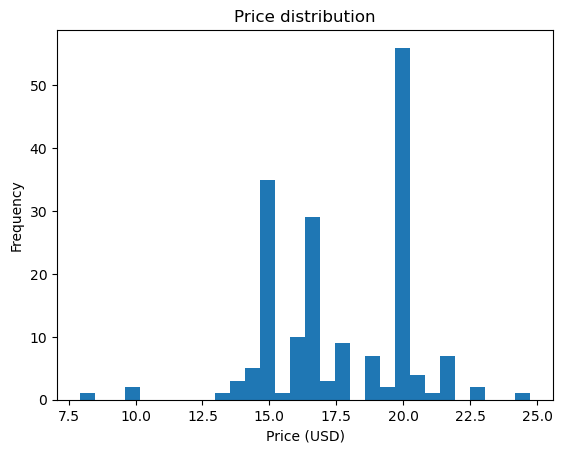

In [7]:
# price analysis
plt.hist(df_products['Price'], bins = 30)
plt.title('Price distribution')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

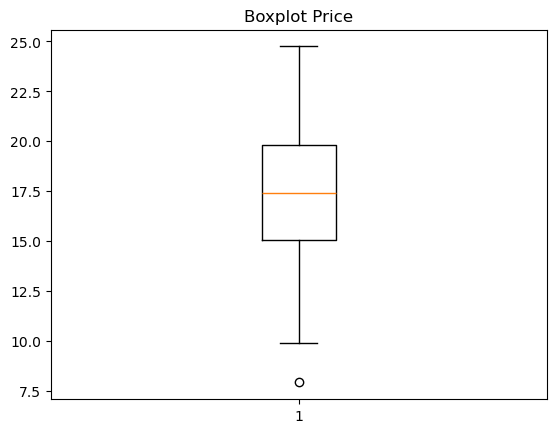

In [8]:
# detect outliers
plt.boxplot(df_products['Price'])
plt.title('Boxplot Price')
plt.show()

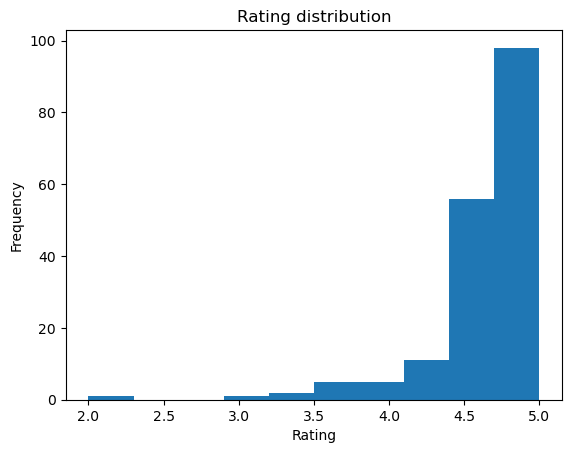

In [10]:
# rating analysis
plt.hist(df_products['Rating'], bins = 10)
plt.title('Rating distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

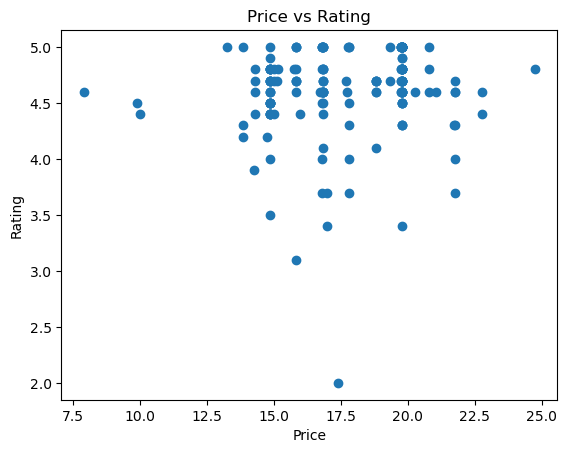

In [12]:
# price vs rating
plt.scatter(df_products['Price'], df_products['Rating'])
plt.xlabel('Price')
plt.ylabel('Rating')
plt.title('Price vs Rating')
plt.show()

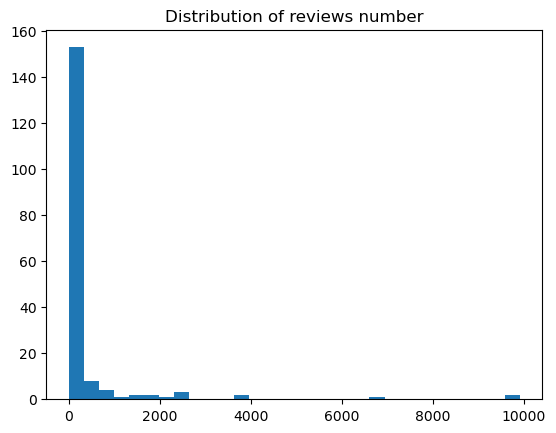

In [13]:
# popularity
plt.hist(df_products['Review Count'], bins = 30)
plt.title('Distribution of reviews number')
plt.show()

In [14]:
# top products
df_products.sort_values(by = 'Review Count', ascending = False).head(10)

,ASIN,Title,Price,Rating,Review Count,Date,URL
32,B00NMFDFHA,Never Forget Mens Cassette Tape VHS Music Old ...,18.81,4.7,9909,2026-03-26,https://www.amazon.com/dp/B00NMFDFHA
29,B00NMFDCOG,Never Forget Mens Cassette Tape VHS Music Old ...,18.81,4.7,9909,2026-03-26,https://www.amazon.com/dp/B00NMFDCOG
126,B0G55ZD87S,I'm Currently Unsupervised Novelty Graphic Sar...,14.85,4.7,6772,2026-03-26,https://www.amazon.com/dp/B0G55ZD87S
118,B07CXJ59G9,Funny Mens Shirts Sarcastic Tees with Funny Sa...,14.85,4.6,3926,2026-03-26,https://www.amazon.com/dp/B07CXJ59G9
14,B00HWEI6S0,"Never Trust an Atom, They Make Up Everything |...",14.85,4.8,3692,2026-03-26,https://www.amazon.com/dp/B00HWEI6S0
106,B07TVX7R72,What Part Of Don't You Understand | Funny Math...,21.78,4.7,2422,2026-03-26,https://www.amazon.com/dp/B07TVX7R72
125,B00TEAYRTW,May The (F=m*dv/dt) Be with You - Funny Physic...,14.85,4.8,2404,2026-03-26,https://www.amazon.com/dp/B00TEAYRTW
119,B0G44ZGN2W,May The (F=m*dv/dt) Be with You - Funny Physic...,14.85,4.8,2404,2026-03-26,https://www.amazon.com/dp/B0G44ZGN2W
37,B0GN58ST77,People Who Tolerate Me On A Daily Basis They a...,14.85,4.7,2135,2026-03-26,https://www.amazon.com/dp/B0GN58ST77
116,B0868WK9P8,Crazy Dog Mens T Shirts Funny Sarcastic Humor ...,14.85,4.4,1949,2026-03-26,https://www.amazon.com/dp/B0868WK9P8


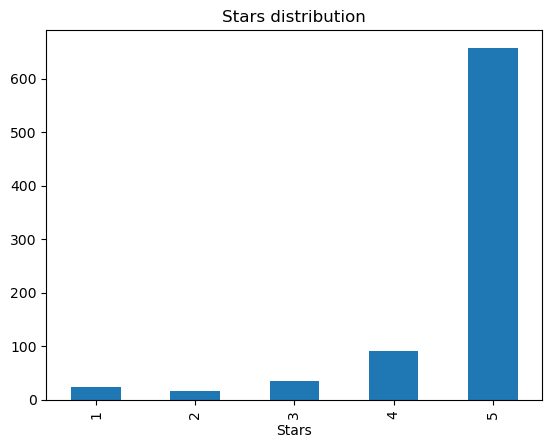

In [15]:
# review analyis
df_reviews['Stars'].value_counts().sort_index().plot(kind = 'bar')
plt.title('Stars distribution')
plt.show()

In [16]:
# real average
df_reviews['Stars'].mean()

np.float64(4.626666666666667)

In [20]:
# verified purchase
df_reviews['Verified_Purchase'].value_counts()

Verified_Purchase
Verified Purchase    817
No                     8
Name: count, dtype: int64

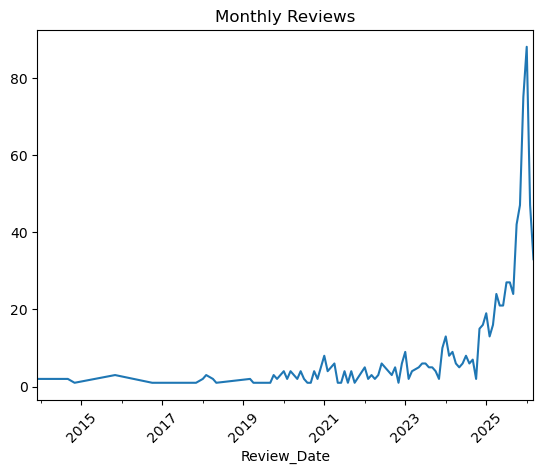

In [25]:
# evolution of reviews through time
df_reviews['Review_Date'] = pd.to_datetime(df_reviews['Review_Date'])

df_reviews.groupby(df_reviews['Review_Date'].dt.to_period('M')).size().plot(kind = 'line')
plt.xticks(rotation = 45)
plt.title('Monthly Reviews')
plt.show()

In [22]:
# products vs reviews
# average stars by product
avg_reviews = df_reviews.groupby('ASIN')['Stars'].mean().reset_index()
df_merged = df_products.merge(avg_reviews, on = 'ASIN', how = 'left')

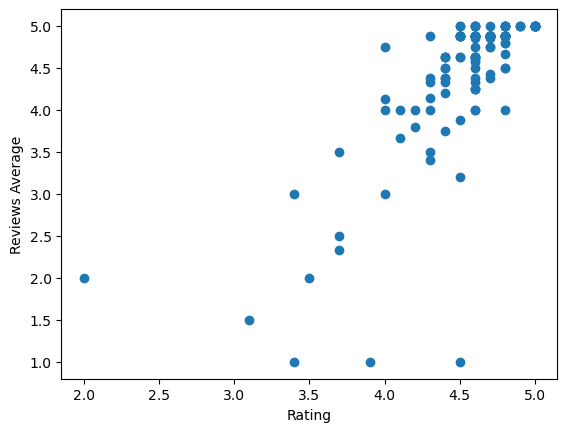

In [23]:
plt.scatter(df_merged['Rating'], df_merged['Stars'])
plt.xlabel('Rating')
plt.ylabel('Reviews Average')
plt.show()

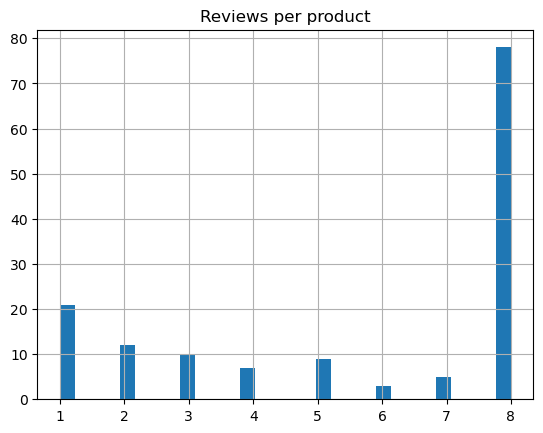

In [24]:
# reviews per product
reviews_per_product = df_reviews.groupby('ASIN').size()

reviews_per_product.hist(bins = 30)
plt.title('Reviews per product')
plt.show()